In [2]:
import pandas as pd

# Read the Excel files into DataFrames
df = pd.read_excel('Processed_Images_Data_classified.xlsx')
# Filter the DataFrame to contain only rows where 'classification' is 0
df1 = df[df['lympho_pred'] == 0]

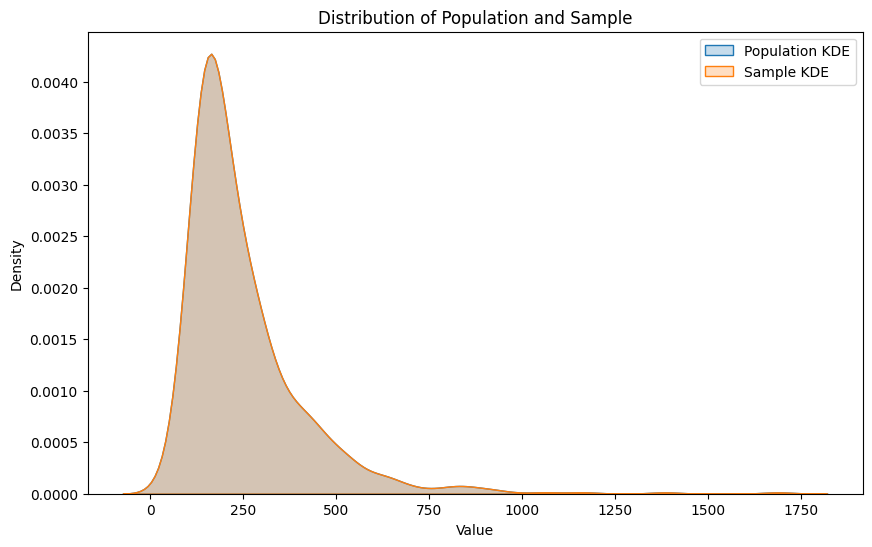

KS Test Statistic (Sample vs. Population): 0.0
KS Test p-value (Sample vs. Population): 1.0
[{'cluster': np.int32(1), 'mean': array([172.22422791]), 'variance': array([57.27723409])}, {'cluster': np.int32(2), 'mean': array([853.56646729]), 'variance': array([259.67547819])}, {'cluster': np.int32(3), 'mean': array([418.04000854]), 'variance': array([92.62299761])}]


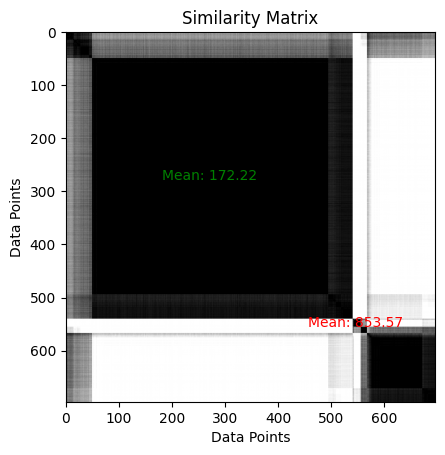

/tmp/ipykernel_1753242/2310285893.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)


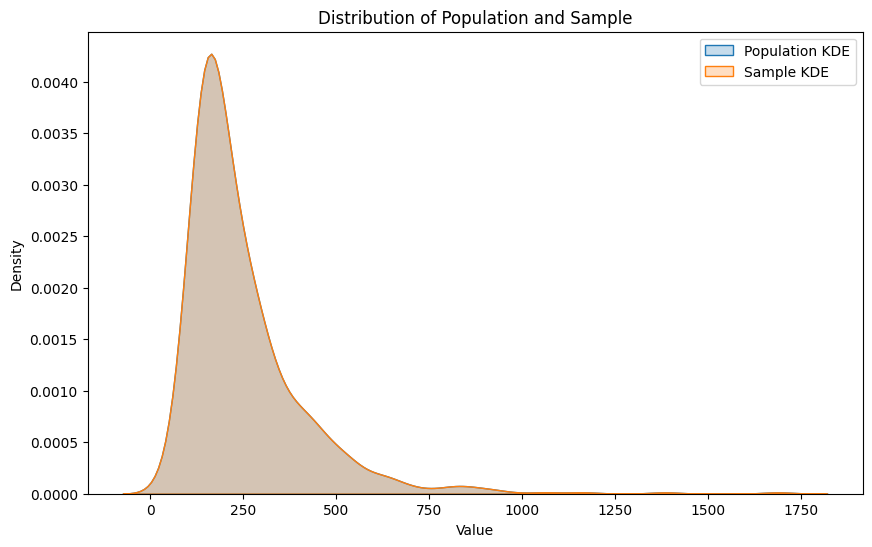

KS Test Statistic (Sample vs. Population): 0.0
KS Test p-value (Sample vs. Population): 1.0
[{'cluster': np.int32(1), 'mean': array([172.99645996]), 'variance': array([57.88362431])}, {'cluster': np.int32(2), 'mean': array([853.56646729]), 'variance': array([259.67547819])}, {'cluster': np.int32(3), 'mean': array([423.85879517]), 'variance': array([91.83864685])}]


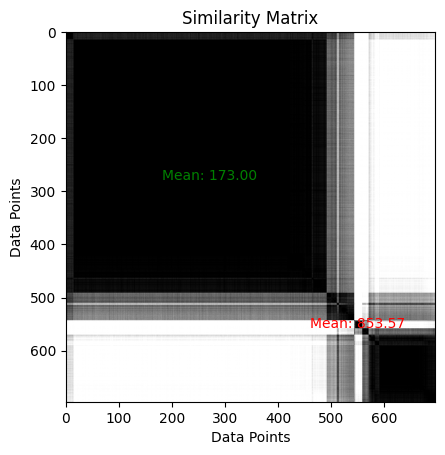

/tmp/ipykernel_1753242/2310285893.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)
/tmp/ipykernel_1753242/2310285893.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)
/tmp/ipykernel_1753242/2310285893.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / len(np.unique(cluster_labels)))


Number of Clusters: 3
Average Silhouette Score: 0.6660700849809025
Average Area under CDF: 0.598202738698788


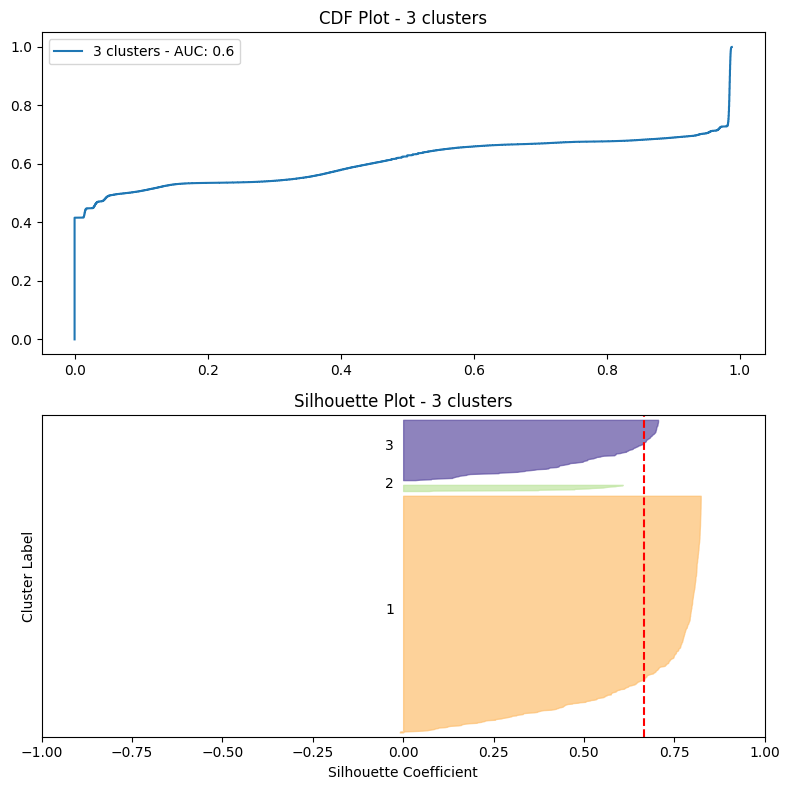

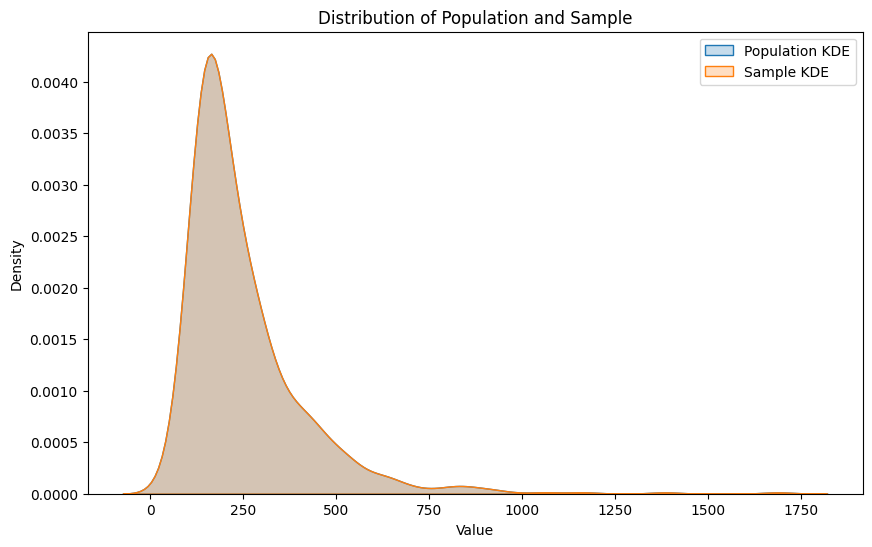

KS Test Statistic (Sample vs. Population): 0.0
KS Test p-value (Sample vs. Population): 1.0
[{'cluster': np.int32(1), 'mean': array([152.53819275]), 'variance': array([36.25172108])}, {'cluster': np.int32(2), 'mean': array([288.51922607]), 'variance': array([46.76376556])}, {'cluster': np.int32(3), 'mean': array([882.99835205]), 'variance': array([259.48769509])}, {'cluster': np.int32(4), 'mean': array([485.79174805]), 'variance': array([80.45335602])}]


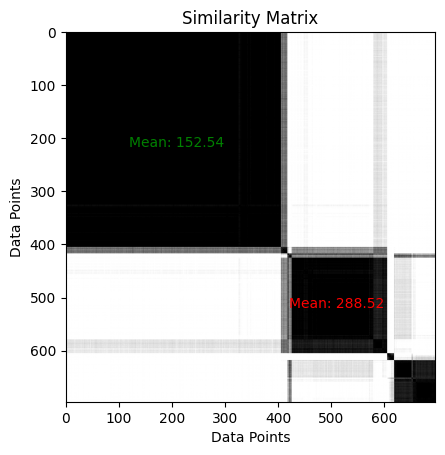

/tmp/ipykernel_1753242/2310285893.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)


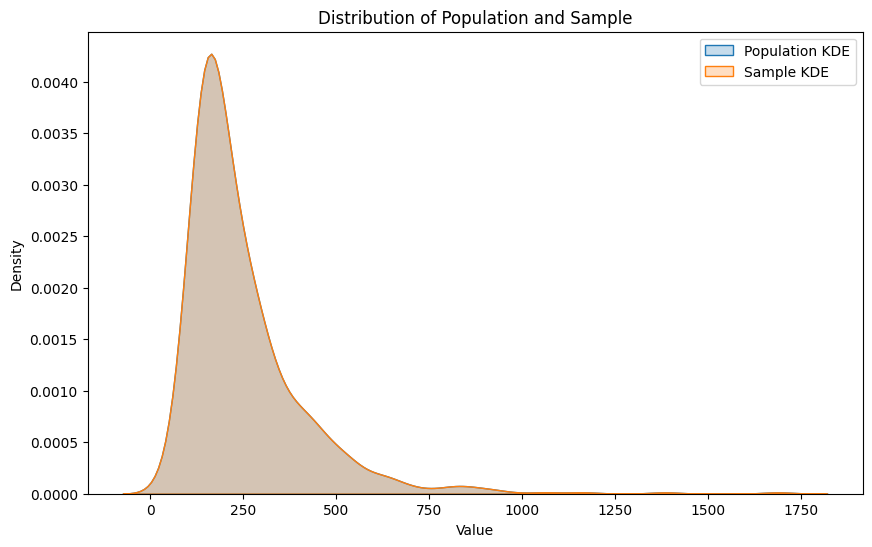

KS Test Statistic (Sample vs. Population): 0.0
KS Test p-value (Sample vs. Population): 1.0
[{'cluster': np.int32(1), 'mean': array([151.070755]), 'variance': array([34.85482235])}, {'cluster': np.int32(2), 'mean': array([282.73973083]), 'variance': array([44.57346894])}, {'cluster': np.int32(3), 'mean': array([882.99835205]), 'variance': array([259.48769509])}, {'cluster': np.int32(4), 'mean': array([470.82699585]), 'variance': array([82.75005067])}]


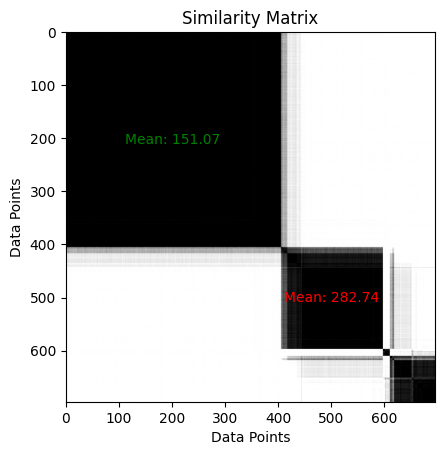

/tmp/ipykernel_1753242/2310285893.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)
/tmp/ipykernel_1753242/2310285893.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(cdf, sorted_similarities)
/tmp/ipykernel_1753242/2310285893.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / len(np.unique(cluster_labels)))


Number of Clusters: 4
Average Silhouette Score: 0.6159787281680819
Average Area under CDF: 0.43670958085083966


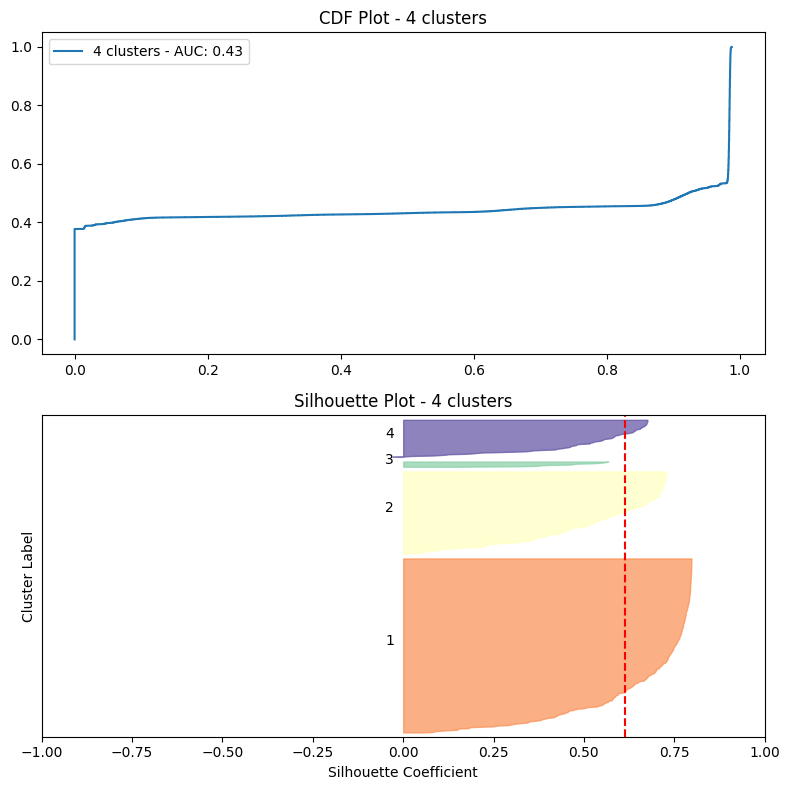

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples
from consensus_clustering import cluster_similarities, consensus_clustering
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from scipy.stats import ks_2samp


# Define your utility functions here
def euclidean_distance(x, y):
    return np.linalg.norm(x - y)

def assign_to_cluster(row, clusters_info):
    min_distance = float('inf')
    assigned_cluster = None
    for cluster, info in clusters_info.items():
        distance = euclidean_distance(row['mean_cd3'], info['mean'])
        if distance < min_distance:
            min_distance = distance
            assigned_cluster = cluster
    return assigned_cluster

def find_cluster_stats(X, flat_clusters):
    cluster_stats = []
    unique_clusters = np.unique(flat_clusters)

    for cluster in unique_clusters:
        cluster_points = X[flat_clusters == cluster]
        cluster_mean = np.median(cluster_points, axis=0)
        cluster_variance = np.std(cluster_points, axis=0)
        cluster_stats.append({'cluster': cluster, 'mean': cluster_mean, 'variance': cluster_variance})

    return cluster_stats

def plot_cdf_similarity(similarity_matrix, n_clusters, ax):
    pairwise_similarities = similarity_matrix.flatten()
    sorted_similarities = np.sort(pairwise_similarities)
    cdf = np.arange(len(sorted_similarities)) / float(len(sorted_similarities))
    area_under_curve = np.trapz(cdf, sorted_similarities)

    ax.plot(sorted_similarities, cdf, label=f'{n_clusters} clusters - AUC: {round(area_under_curve, 2)}')

def plot_silhouette(X, cluster_labels, ax):
    silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in np.unique(cluster_labels):
        ith_cluster_silhouette_values = silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.get_cmap("Spectral")(float(i) / len(np.unique(cluster_labels)))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    silhouette_avg = silhouette_values.mean()
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, y_upper + 10)
    ax.set_yticks([])
    ax.set_title(f"Silhouette Plot - {len(np.unique(cluster_labels))} clusters")

# Load data
df = df1  # Replace 'con_df' with your actual data source

# Initialize dictionaries to store results
silhouette_scores_dict = {}
auc_scores_dict = {}
wcss_scores = []  # Initialize a list to store WCSS scores

# After: df = df1
# Make X a 1-column DataFrame
X_df = df[['mean_cd3']].dropna().reset_index(drop=True)   # DataFrame (n,1)
x_series = X_df['mean_cd3']                                # convenience Series for plots

for n_clusters in range(3, 5):
    silhouette_scores, auc_scores = [], []

    for repetition in range(2):
        # consensus clustering expects a DataFrame
        df_out = consensus_clustering(X_df, n_clusters=n_clusters, n_iterations=100, percentage=0.8)
        consensus_matrix, M_ordered, flat_clusters, res_o = cluster_similarities(df_out, n_clusters=n_clusters)

        # KDEs on population vs sample
        population_data = df['mean_cd3'].dropna()
        sample_data = x_series
        plt.figure(figsize=(10, 6))
        sns.kdeplot(population_data, label='Population KDE', fill=True)
        sns.kdeplot(sample_data, label='Sample KDE', fill=True)
        plt.xlabel('Value'); plt.ylabel('Density'); plt.title('Distribution of Population and Sample')
        plt.legend(); plt.show()

        # KS test
        from scipy.stats import ks_2samp
        ks_statistic, ks_p_value = ks_2samp(population_data, sample_data)
        print(f"KS Test Statistic (Sample vs. Population): {ks_statistic}")
        print(f"KS Test p-value (Sample vs. Population): {ks_p_value}")

        # Cluster stats (expects arrays; flat_clusters length == len(X_df))
        cluster_stats = find_cluster_stats(X_df.values, flat_clusters)
        print(cluster_stats)

        # Block sizes for annot placement
        n1 = flat_clusters[res_o[0]]
        L1 = int(np.sum(flat_clusters == n1))
        n2 = flat_clusters[res_o[L1]]
        L2 = int(np.sum(flat_clusters == n2))

        # Means
        mean1 = cluster_stats[0]['mean'][0]
        mean2 = cluster_stats[1]['mean'][0]
        mean_values = [mean1, mean2]
        min_mean, max_mean = min(mean_values), max(mean_values)
        colors = {min_mean: 'green', max_mean: 'red'}

        plt.imshow(M_ordered, cmap='gray')
        plt.xlabel('Data Points'); plt.ylabel('Data Points'); plt.title('Similarity Matrix')
        for i, mean in enumerate(mean_values):
            color = colors[mean]
            if i == 0:
                plt.text(L1 // 2, L1 // 2, f'Mean: {mean:.2f}', color=color, ha='center', va='center', fontsize=10)
            elif i == 1:
                plt.text(L1 + (L2 // 2), L1 + (L2 // 2), f'Mean: {mean:.2f}', color=color, ha='center', va='center', fontsize=10)
        plt.show()

        # Silhouette: needs (n,1)
        from sklearn.metrics import silhouette_samples
        sil_vals = silhouette_samples(X_df.values, flat_clusters)
        silhouette_avg = sil_vals.mean()

        # AUC of CDF
        pairwise_similarities = consensus_matrix.flatten()
        sorted_similarities = np.sort(pairwise_similarities)
        cdf = np.arange(len(sorted_similarities)) / float(len(sorted_similarities))
        area_under_curve = np.trapz(cdf, sorted_similarities)

        silhouette_scores.append(silhouette_avg)
        auc_scores.append(area_under_curve)

    silhouette_scores_dict[n_clusters] = silhouette_scores
    auc_scores_dict[n_clusters] = auc_scores

    avg_silhouette_scores = np.mean(silhouette_scores)
    avg_auc_scores = np.mean(auc_scores)

    # KMeans expects 2D
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(X_df.values)
    wcss_scores.append(kmeans.inertia_)

    print(f"Number of Clusters: {n_clusters}")
    print(f"Average Silhouette Score: {avg_silhouette_scores}")
    print(f"Average Area under CDF: {avg_auc_scores}")

    cluster_stats.sort(key=lambda x: x['mean'][0])

    cluster_mapping = {cluster_info['cluster']: i + 1 for i, cluster_info in enumerate(cluster_stats)}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    plot_cdf_similarity(consensus_matrix, n_clusters, ax1)
    plot_silhouette(X_df.values, flat_clusters, ax2)
    ax1.set_title(f"CDF Plot - {n_clusters} clusters"); ax1.legend()
    plt.tight_layout(); plt.show()
